In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
import torch
import torchmetrics

In [3]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import datasets
import models
import utils

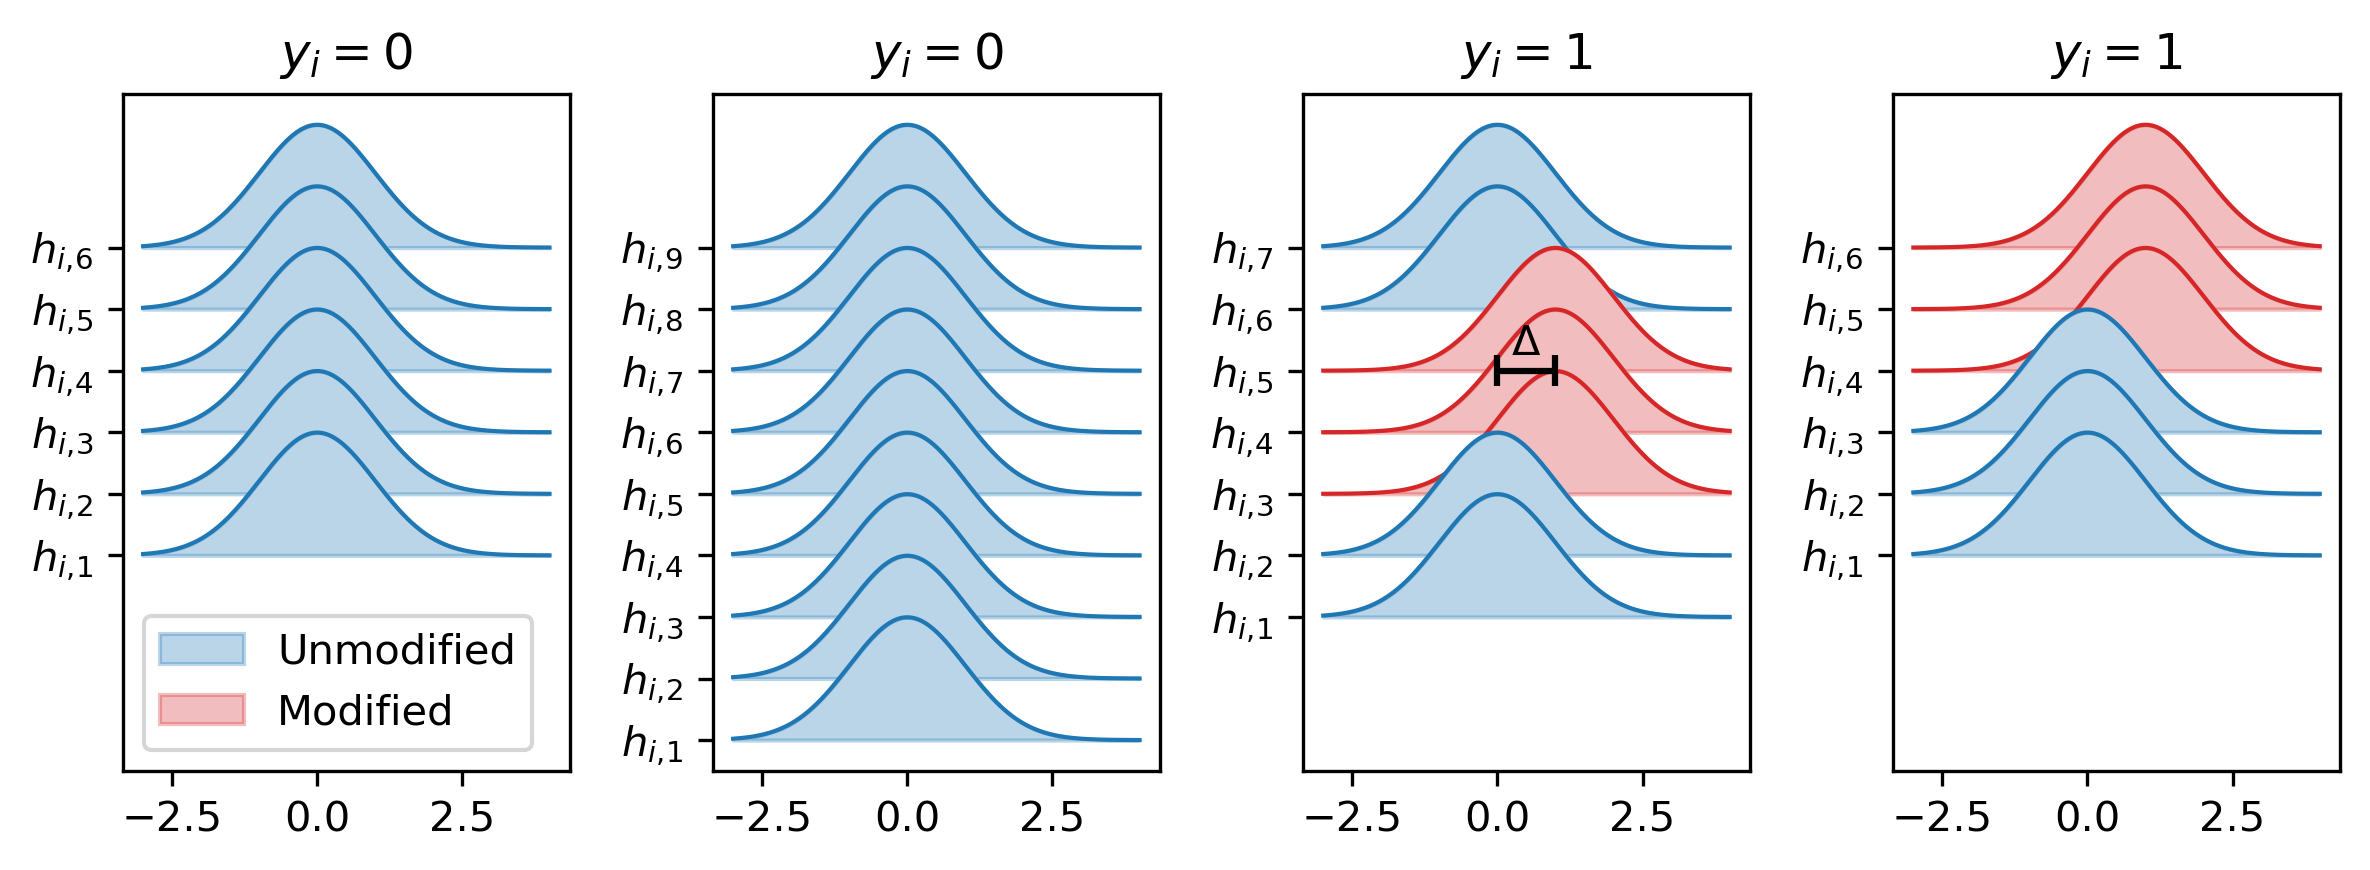

In [5]:
dataset = datasets.ShiftedMeanMILDataset(n=4, r=3, s_low=6, s_high=9, k=1, m=1, p_y1=0.5, delta=1.0, mu=0.0, sigma=1.0, seed=2)

ncols, nrows = 4, 1
fig, axs = plt.subplots(dpi=300, figsize=(2*ncols, 3*nrows), ncols=ncols, nrows=nrows)

offset = 0.2

for i in range(dataset.n):
    
    for j in range(dataset.lengths[i]):
        
        is_modified = dataset.u[i] <= j < dataset.u[i] + dataset.r and dataset.y[i] == 1
        color = "#D62728" if is_modified else "#1F77B4"
        x_axis = torch.linspace(start=-3, end=3 + dataset.delta, steps=1000)
        y_axis = utils.normal_pdf(x_axis, dataset.delta, 1) if is_modified else utils.normal_pdf(x_axis, 0, 1)
        
        y_offset = (max(dataset.lengths) * offset) - (j * offset)
        axs[i].fill_between(x_axis, y_offset, y_axis + y_offset, alpha=1.0, color="#FFFFFF", zorder=0)
        axs[i].fill_between(x_axis, y_offset, y_axis + y_offset, alpha=0.3, color=color, zorder=0)
        axs[i].plot(x_axis, y_axis + y_offset, color=color, linewidth=1, zorder=0)
    
    axs[i].scatter(0, offset, alpha=0.0)
    axs[i].set_yticks([(max(dataset.lengths) * offset) - (j * offset) for j in range(dataset.lengths[i])])
    axs[i].set_yticklabels([rf"$h_{{i,\!{j}}}$" for j in range(1, dataset.lengths[i]+1)][::-1])
    axs[i].set_title(rf"$y_i={int(dataset.y[i])}$")
    
i = (dataset.y == 1).int().argmax()
x0, x1 = 0, dataset.delta
y0 = (max(dataset.lengths) * offset) - ((dataset.u[i]) * offset)
axs[i].vlines(x0, y0 - 0.05, y0 + 0.05, color="#000000")
axs[i].hlines(y0, x0, x1, color="#000000")
axs[i].vlines(x1, y0 - 0.05, y0 + 0.05, color="#000000")
axs[i].text((x0 + x1) / 2, y0 + 0.05, r"$\Delta$", ha="center")

axs[0].fill_between([], [], [], alpha=0.3, color="#1F77B4", label="Unmodified")
axs[0].fill_between([], [], [], alpha=0.3, color="#D62728", label="Modified")
axs[0].legend(loc="lower left")

fig.tight_layout()
fig.savefig("synthetic_data_visualization.pdf", bbox_inches="tight")
plt.show()

In [12]:
auroc = torchmetrics.AUROC(task="binary")

deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
bayes_aurocs = []

for delta in deltas:

    test_dataset = datasets.ShiftedMeanMILDataset(n=100, r=3, delta=delta, seed=2)
    
    bayes_probs = torch.stack([test_dataset.p_y1_given_h(i) for i in range(len(test_dataset))])
    bayes_aurocs.append(auroc(bayes_probs, test_dataset.y).item())
    
print(bayes_aurocs)

[0.6298990249633789, 0.7652524709701538, 0.8828282952308655, 0.9684849381446838, 0.994747519493103, 0.9995959997177124, 1.0, 1.0, 0.9999999403953552, 1.0]


NameError: name 'Deltas' is not defined

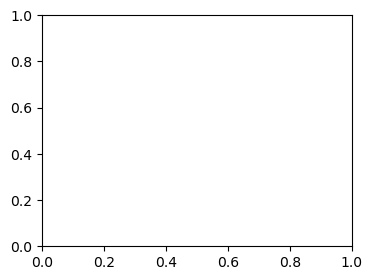

In [13]:
ncols, nrows = 1, 1
fig, ax = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows)

ax.plot(Deltas, bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$", marker="o")
ax.plot([0.5], [0.5], color="#FFFFFF")
ax.set_title(r"$R=3$")
ax.set_xlabel(r"Seperation $\Delta$")
ax.set_ylabel("Test AUROC")
ax.legend(loc="lower right")
ax.grid()

fig.tight_layout()
plt.show()